# Tranfer Learning VGG16 Chapter 10 Workshop 1

## Load module

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf


## Declare variable

In [4]:
target_img_shape = (224, 224)

train_dir = r'D:\Project\Learning\TensorFlow_Files\datasets\train_set'
test_dir = r'D:\Project\Learning\TensorFlow_Files\datasets\test_set'
val_dir = r'D:\Project\Learning\TensorFlow_Files\datasets\val_set'

# Define process input for VGG
# train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
# Define process input for VGG with Data Augmentation
train_datagen = ImageDataGenerator(
                            preprocessing_function=preprocess_input,
                            rotation_range=20,
                            width_shift_range=0.15,
                            height_shift_range=0.15,
                            shear_range=0.2,
                            zoom_range=0.2,
                            horizontal_flip=True,
                            fill_mode='nearest'
)

train_set = train_datagen.flow_from_directory(train_dir,
                                                  target_size=target_img_shape,
                                                  batch_size=32,
                                                  class_mode='binary')


val_datagen = ImageDataGenerator(
                            preprocessing_function=preprocess_input,
                            rotation_range=20,
                            width_shift_range=0.15,
                            height_shift_range=0.15,
                            shear_range=0.2,
                            zoom_range=0.2,
                            horizontal_flip=True,
                            fill_mode='nearest'
)

val_set = val_datagen.flow_from_directory(val_dir,
                                                  target_size=target_img_shape,
                                                  batch_size=32,
                                                  class_mode='binary')

Found 15997 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


## Check data_set

In [5]:
batch = next(train_set) # train_set.next()
print(batch[0].shape)
print(batch[1].shape)

(32, 224, 224, 3)
(32,)


[0 0 0 ... 1 1 1]
(32, 224, 224, 3)
(32,)
['dog', 'dog', 'dog', 'dog', 'dog', 'cat', 'cat', 'cat', 'dog', 'dog', 'dog', 'dog', 'cat', 'cat', 'cat', 'cat', 'cat', 'dog', 'cat', 'cat', 'dog', 'dog', 'cat', 'cat', 'cat', 'cat', 'dog', 'cat', 'cat', 'cat', 'cat', 'cat']
-105.392525 131.50665


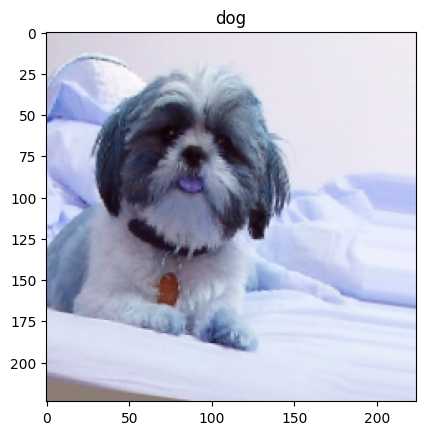

In [6]:
print(train_set.labels)
labels = train_set.class_indices
labels = {v: k for k, v in labels.items()} # dict((v, k) for k, v in labels_batch[0].items())

for image_batch, labels_batch in train_set:
    print(image_batch.shape)
    print(labels_batch.shape)
    
    labels_batch =  list(map(lambda x: labels[x], labels_batch))
    print(labels_batch)

    img = image_batch[0] - np.min(image_batch[0])
    img = img / np.max(img)

    print(np.min(image_batch[0]), np.max(image_batch[0]))
    plt.imshow(img)
    plt.title(labels_batch[0])
    
    break

In [7]:
ids, counts = np.unique(train_set.classes, return_counts=True)
print(ids)
print(counts)

[0 1]
[7997 8000]


In [8]:
for i in ids:
    print(labels[i], counts[i])

cat 7997
dog 8000


## Create model

### Create base model

In [9]:
in_shape = (target_img_shape[0], target_img_shape[1], 3)
in_shape

(224, 224, 3)

#### base model from VGG16 instance

In [10]:
base_model = VGG16(weights='imagenet', 
                   include_top=False, 
                   input_shape=in_shape)
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

#### base model from saved model

In [ ]:
# from tensorflow.keras.models import Model, load_model

# # Load the full VGG16 model (with top layers)
# raw_model = load_model('./model/vgg16_model.h5')

# # Inspect the layers (optional)
# for i, layer in enumerate(raw_model.layers):
#     print(i, layer.name)

# # Get the last layer of the convolutional base
# # For VGG16, this is usually 'block5_pool'
# conv_base_output = raw_model.get_layer('block5_pool').output

# # Create a new model with the same input but truncated after the conv base
# base_model_from_raw = Model(inputs=raw_model.input, outputs=conv_base_output)

# # Now base_model_from_raw behaves like base_model1
# base_model_from_raw.summary()

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = './model/vgg16_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

### Combine base model with new top

In [12]:
model = Sequential()

model.add(base_model) # base_model_from_raw 
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 17,926,209 (68.38 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
for layer in model.layers:
    print(layer.name, layer.trainable)

vgg16 True
flatten True
dense True
dense_1 True


### Freeze Feature Extraction layer

In [14]:
# base_model_from_raw.trainable = False
base_model.trainable = False

In [15]:
print("Trainable..\n---")
for var in model.trainable_variables:
    print(var.name)

model.summary()

Trainable..
---
kernel
bias
kernel
bias


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 3,211,521 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Compile model

In [16]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

## Train model

In [18]:
import time

es = EarlyStopping(monitor='val_loss',
                   patience=5,
                   verbose=1,
                   restore_best_weights=True)
mc = ModelCheckpoint('model/test_model_with_gpu.h5',
                       monitor='val_accuracy',
                       save_best_only=True,
                       verbose=1)

start = time.time()
# with tf.device('/GPU:0'):
#     history = model.fit(train_set,
#                         steps_per_epoch=len(train_set),
#                         epochs=20,
#                         validation_data=val_set,
#                         callbacks=[es, mc],
#                         verbose=1
#                         )

history = model.fit(train_set,
                        steps_per_epoch=len(train_set),
                        epochs=20,
                        validation_data=val_set,
                        callbacks=[es, mc],
                        verbose=1
                        )

end = time.time()

print("Training time: ", round(end - start)/60, 2, "minites")


d:\Project\Learning\Environment_Project\tensorflow\evn1\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
 15/500 ━━━━━━━━━━━━━━━━━━━━ 6:43 831ms/step - accuracy: 0.7595 - loss: 9.5147

KeyboardInterrupt: 

In [1]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.10.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
